# <center>Homework 98</center>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from importlib import reload
import perceptron
from sklearn.metrics import f1_score, accuracy_score, root_mean_squared_error
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

## Task 2

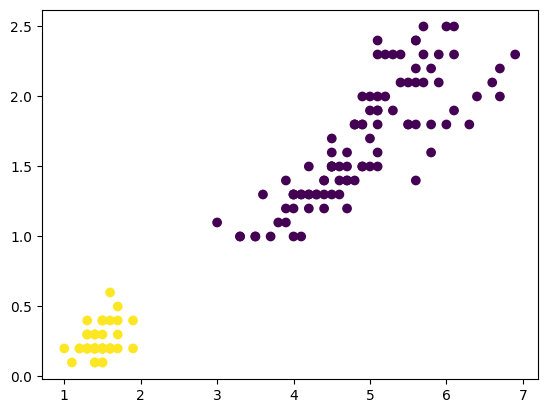

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Iris setosa

np.random.seed(42)
inxs = np.random.permutation(len(X))
X = X[inxs]
y = y[inxs]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True)


plt.scatter(X[:, 0], X[:, 1], c=y)
# plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

,Custom,Original
F1,1.00000,1.00000
Iter,24.00000,52.00000
Loss,0.02721,0.00109


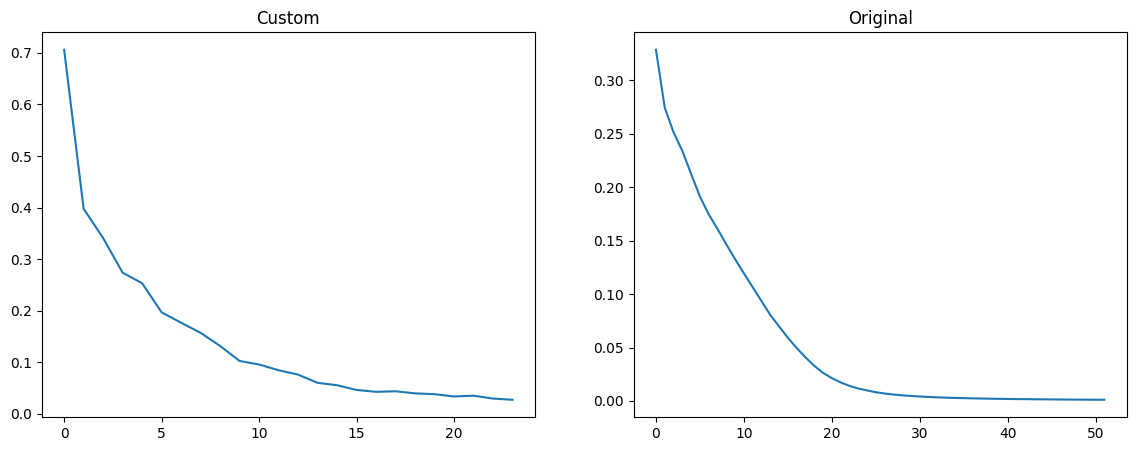

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

reload(perceptron)
from perceptron import MLPClassifier

mlp = MLPClassifier((10, 10), batch_size=50, random_state=42, learning_rate_init=0.1, tol=0.01).fit(X, y)
y_pred_custom = mlp.predict(X)
ax[0].plot(np.arange(mlp.n_iter_), mlp.loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPClassifier
mlp_org = MLPClassifier((10, 10), batch_size=50, random_state=42, learning_rate='constant', learning_rate_init=0.01).fit(X, y)
y_pred_org = mlp_org.predict(X)
ax[1].plot(np.arange(mlp_org.n_iter_), mlp_org.loss_curve_)
ax[1].set_title('Original')


pd.DataFrame([
    [f1_score(y, y_pred_custom), f1_score(y, y_pred_org)],
    [mlp.n_iter_, mlp_org.n_iter_],
    [mlp.loss_, mlp_org.loss_]
], ['F1', 'Iter', 'Loss'], ['Custom', 'Original'])

In [18]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True)

np.random.seed(42)
inxs = np.random.permutation(len(X))
X = X[inxs]
y = y[inxs]

learning_rate='constant'

,Custom,Original
F1,0.876847,0.979982
n Iters,77.000000,67.000000
Loss,0.263885,0.122172


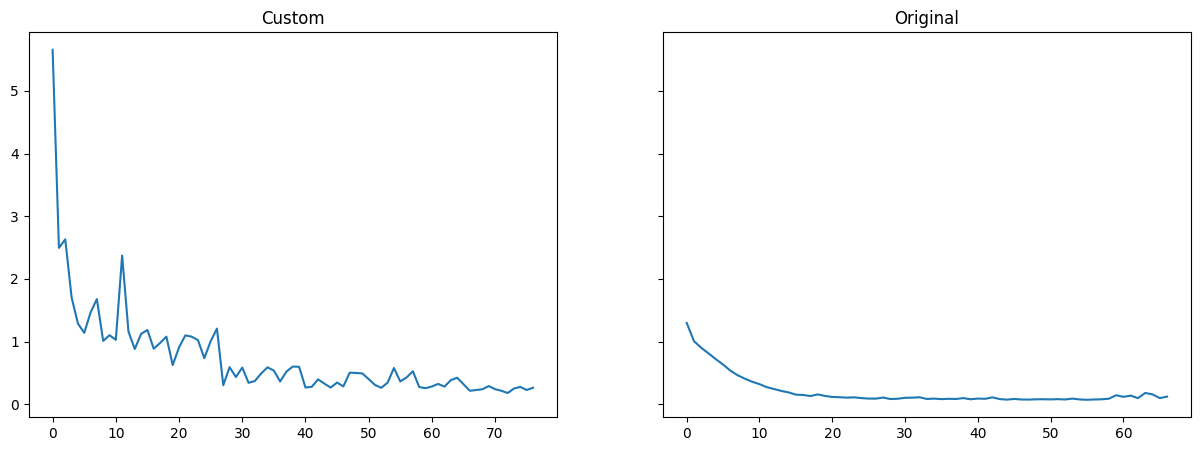

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPClassifier

mlp = MLPClassifier((30, 30), batch_size=50, random_state=42, learning_rate_init=0.01, tol=0.1).fit(X, y)
y_pred = mlp.predict(X)
cus_iter = mlp.n_iter_
cus_loss = mlp.loss_
cus_f1 = f1_score(y, y_pred, average='macro')
ax[0].plot(np.arange(mlp.n_iter_), mlp.loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPClassifier
mlp_org = MLPClassifier((30, 30), batch_size=50, random_state=42, learning_rate='constant', learning_rate_init=0.01).fit(X, y)
y_pred = mlp_org.predict(X)
org_f1 = f1_score(y, y_pred, average='macro')
org_iter = mlp_org.n_iter_
org_loss = mlp_org.loss_
ax[1].plot(np.arange(mlp_org.n_iter_), mlp_org.loss_curve_)
ax[1].set_title('Original')

pd.DataFrame([
    [cus_f1, org_f1],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['F1', 'n Iters', 'Loss'], ['Custom', 'Original'])

learning_rate='invscaling'

,Custom,Original
F1,0.939994,0.960000
n Iters,14.000000,51.000000
Loss,0.238492,0.097231


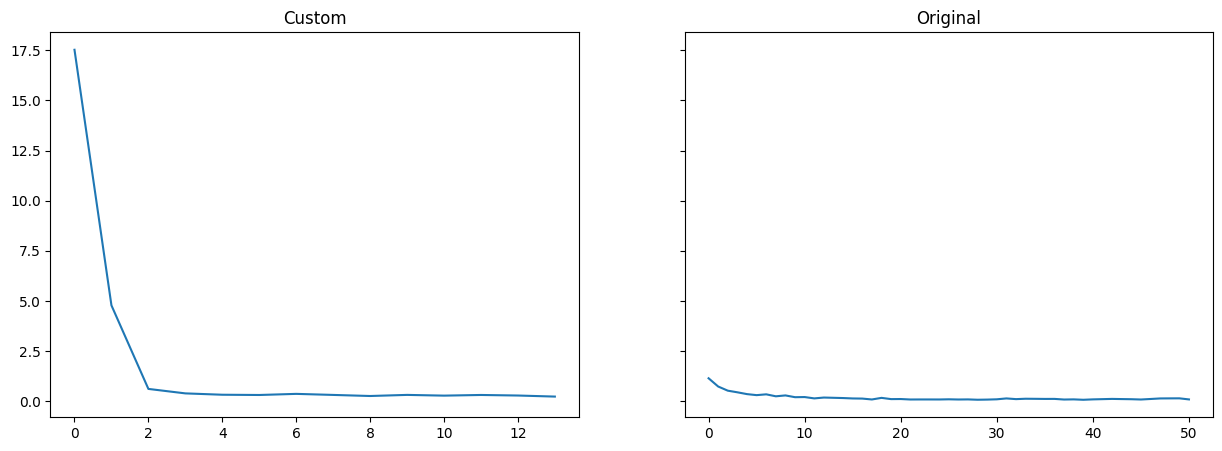

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPClassifier

mlp = MLPClassifier((30, 30), batch_size=50, random_state=42, learning_rate='invscaling', learning_rate_init=0.1, tol=0.1).fit(X, y)
y_pred = mlp.predict(X)
cus_iter = mlp.n_iter_
cus_loss = mlp.loss_
cus_f1 = f1_score(y, y_pred, average='macro')
ax[0].plot(np.arange(mlp.n_iter_), mlp.loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPClassifier
mlp_org = MLPClassifier((30, 30), batch_size=50, random_state=42, learning_rate='invscaling', learning_rate_init=0.1).fit(X, y)
y_pred = mlp_org.predict(X)
org_f1 = f1_score(y, y_pred, average='macro')
org_iter = mlp_org.n_iter_
org_loss = mlp_org.loss_
ax[1].plot(np.arange(mlp_org.n_iter_), mlp_org.loss_curve_)
ax[1].set_title('Original')

pd.DataFrame([
    [cus_f1, org_f1],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['F1', 'n Iters', 'Loss'], ['Custom', 'Original'])

learning_rate='adaptive'

,Custom,Original
F1,0.912272,0.979982
n Iters,76.000000,67.000000
Loss,0.229215,0.122172


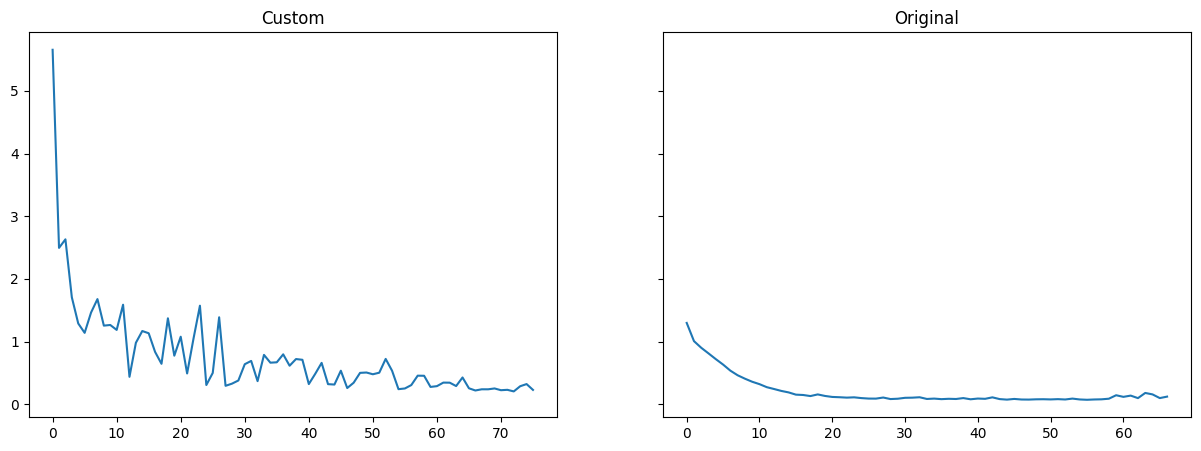

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPClassifier

mlp = MLPClassifier((30, 30), batch_size=50, random_state=42, learning_rate='adaptive', learning_rate_init=0.01, tol=0.1).fit(X, y)
y_pred = mlp.predict(X)
cus_iter = mlp.n_iter_
cus_loss = mlp.loss_
cus_f1 = f1_score(y, y_pred, average='macro')
ax[0].plot(np.arange(mlp.n_iter_), mlp.loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPClassifier
mlp_org = MLPClassifier((30, 30), batch_size=50, random_state=42, learning_rate='adaptive', learning_rate_init=0.01).fit(X, y)
y_pred = mlp_org.predict(X)
org_f1 = f1_score(y, y_pred, average='macro')
org_iter = mlp_org.n_iter_
org_loss = mlp_org.loss_
ax[1].plot(np.arange(mlp_org.n_iter_), mlp_org.loss_curve_)
ax[1].set_title('Original')

pd.DataFrame([
    [cus_f1, org_f1],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['F1', 'n Iters', 'Loss'], ['Custom', 'Original'])

activation='tanh'

,Custom,Original
F1,0.959984,0.959984
n Iters,200.000000,47.000000
Loss,0.149995,0.091917


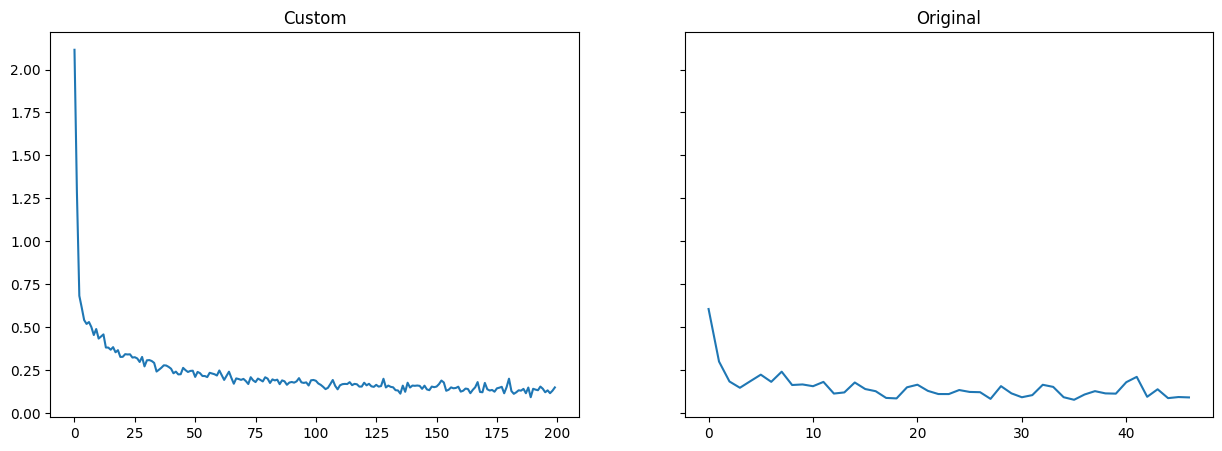

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPClassifier

mlp = MLPClassifier((30, 30), activation='tanh', batch_size=50, random_state=42, learning_rate_init=0.01, tol=0.01).fit(X, y)
y_pred = mlp.predict(X)
cus_iter = mlp.n_iter_
cus_loss = mlp.loss_
cus_f1 = f1_score(y, y_pred, average='macro')
ax[0].plot(np.arange(mlp.n_iter_), mlp.loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPClassifier
mlp_org = MLPClassifier((30, 30), activation='tanh', batch_size=10, random_state=42, learning_rate='constant', learning_rate_init=0.01).fit(X, y)
y_pred = mlp_org.predict(X)
org_f1 = f1_score(y, y_pred, average='macro')
org_iter = mlp_org.n_iter_
org_loss = mlp_org.loss_
ax[1].plot(np.arange(mlp_org.n_iter_), mlp_org.loss_curve_)
ax[1].set_title('Original')

pd.DataFrame([
    [cus_f1, org_f1],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['F1', 'n Iters', 'Loss'], ['Custom', 'Original'])

activation='logistic'

,Custom,Original
F1,0.946645,0.96000
n Iters,200.000000,48.00000
Loss,0.254093,0.08642


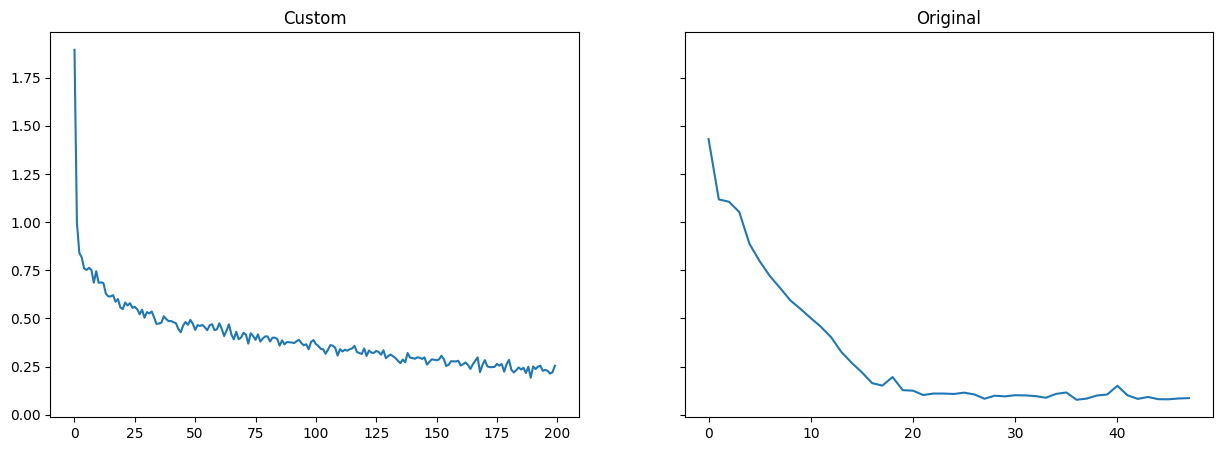

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPClassifier

mlp = MLPClassifier((30, 30), activation='logistic', batch_size=50, random_state=42, learning_rate_init=0.1, tol=0.01).fit(X, y)
y_pred = mlp.predict(X)
cus_iter = mlp.n_iter_
cus_loss = mlp.loss_
cus_f1 = f1_score(y, y_pred, average='macro')
ax[0].plot(np.arange(mlp.n_iter_), mlp.loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPClassifier
mlp_org = MLPClassifier((30, 30), activation='logistic', batch_size=50, random_state=42, learning_rate='constant', learning_rate_init=0.1).fit(X, y)
y_pred = mlp_org.predict(X)
org_f1 = f1_score(y, y_pred, average='macro')
org_iter = mlp_org.n_iter_
org_loss = mlp_org.loss_
ax[1].plot(np.arange(mlp_org.n_iter_), mlp_org.loss_curve_)
ax[1].set_title('Original')

pd.DataFrame([
    [cus_f1, org_f1],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['F1', 'n Iters', 'Loss'], ['Custom', 'Original'])

In [19]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import time

models = [
    MLPClassifier((30, 30, 30), random_state=42),
    RandomForestClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    KNeighborsClassifier(),
    LogisticRegression(random_state=42)
]

In [20]:
data = []
pattern = {'Fit Time': None, 'Train F1': None, 'Test F1': None}

for model in models:
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    current = pattern.copy()
    current['Fit Time'] = end - start
    current['Train F1'] = f1_score(y_train, model.predict(X_train), average='macro')
    current['Test F1']  = f1_score(y_test, model.predict(X_test), average='macro')
    data.append(current)

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [21]:
rows = [m.__class__.__name__ for m in models]
pd.DataFrame(data, rows)

,Fit Time,Train F1,Test F1
MLPClassifier,0.336635,0.950000,0.966583
RandomForestClassifier,0.282187,0.991665,0.966583
DecisionTreeClassifier,0.001456,0.991665,0.966583
KNeighborsClassifier,0.005763,0.958327,0.966583
LogisticRegression,0.038908,0.966646,0.966583


## Task 1

In [28]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
                                                housing.data, housing.target, random_state=42, shuffle=True)

,Custom,Original
RMSE,0.581276,0.538987
n Iters,106.000000,200.000000
Loss,0.310808,0.088796


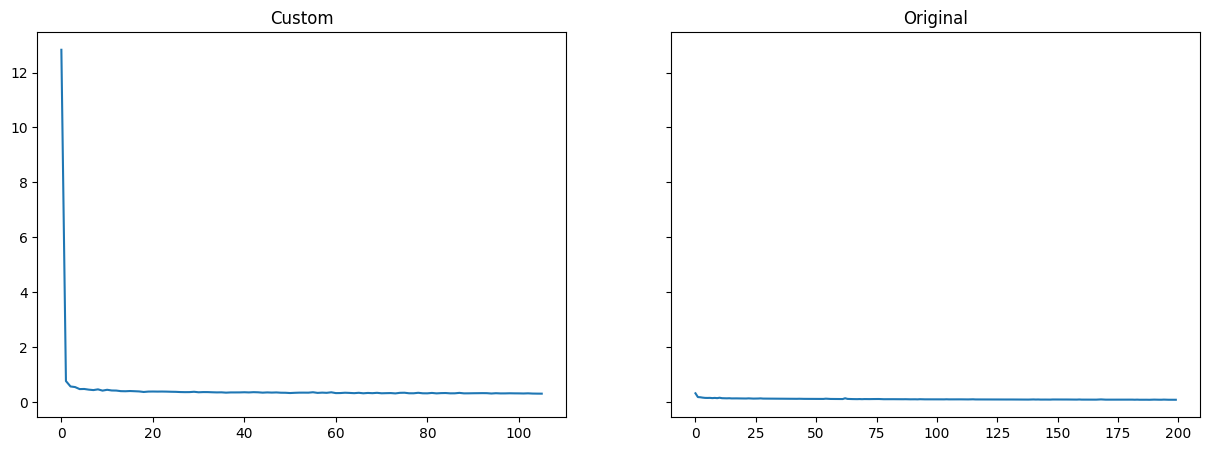

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPRegressor

mlp = MLPRegressor((50, 50, 50), random_state=42, learning_rate_init=0.01, tol=0.01)
mlp = make_pipeline(StandardScaler(), mlp).fit(X_train, y_train)
y_test_pred = mlp.predict(X_test)
cus_iter = mlp[-1].n_iter_
cus_loss = mlp[-1].loss_
cus_rmse = root_mean_squared_error(y_test, y_test_pred)
ax[0].plot(np.arange(cus_iter), mlp[-1].loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPRegressor
mlp_org = MLPRegressor(hidden_layer_sizes=(50, 50, 50), random_state=42, learning_rate='constant', learning_rate_init=0.01)
mlp_org = make_pipeline(StandardScaler(), mlp_org).fit(X_train, y_train)
y_test_pred = mlp_org.predict(X_test)
org_rmse = root_mean_squared_error(y_test, y_test_pred)
org_iter = mlp_org[-1].n_iter_
org_loss = mlp_org[-1].loss_
ax[1].plot(np.arange(org_iter), mlp_org[-1].loss_curve_)
ax[1].set_title('Original')


pd.DataFrame([
    [cus_rmse, org_rmse],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['RMSE', 'n Iters', 'Loss'], ['Custom', 'Original'])

,Custom,Original
RMSE,0.586874,0.528411
n Iters,41.000000,142.000000
Loss,0.341559,0.081166


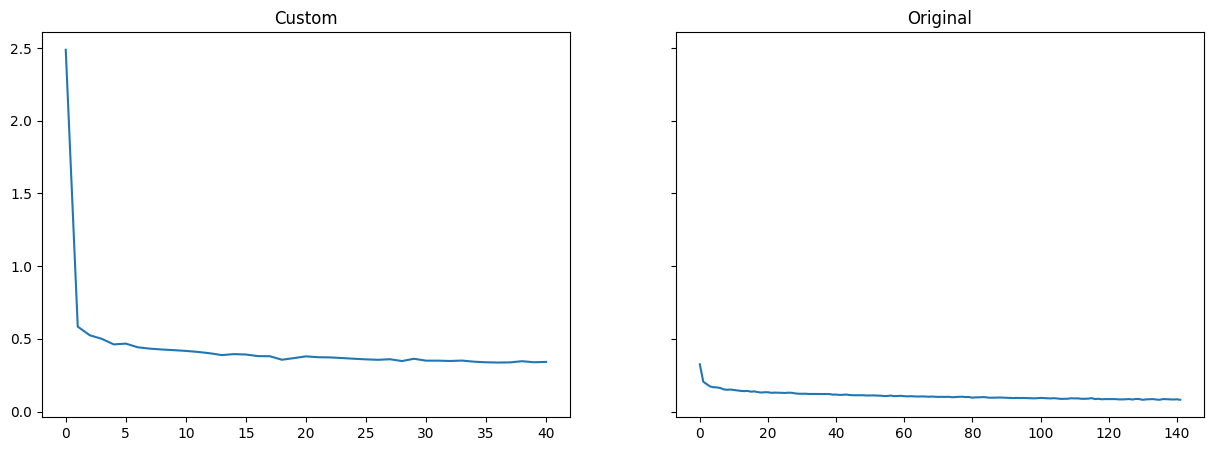

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPRegressor

mlp = MLPRegressor((50, 50, 50), activation='tanh', random_state=42, learning_rate_init=0.01, tol=0.01)
mlp = make_pipeline(StandardScaler(), mlp).fit(X_train, y_train)
y_test_pred = mlp.predict(X_test)
cus_iter = mlp[-1].n_iter_
cus_loss = mlp[-1].loss_
cus_rmse = root_mean_squared_error(y_test, y_test_pred)
ax[0].plot(np.arange(cus_iter), mlp[-1].loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPRegressor
mlp_org = MLPRegressor(hidden_layer_sizes=(50, 50, 50), activation='tanh', random_state=42, learning_rate='constant', learning_rate_init=0.01)
mlp_org = make_pipeline(StandardScaler(), mlp_org).fit(X_train, y_train)
y_test_pred = mlp_org.predict(X_test)
org_rmse = root_mean_squared_error(y_test, y_test_pred)
org_iter = mlp_org[-1].n_iter_
org_loss = mlp_org[-1].loss_
ax[1].plot(np.arange(org_iter), mlp_org[-1].loss_curve_)
ax[1].set_title('Original')


pd.DataFrame([
    [cus_rmse, org_rmse],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['RMSE', 'n Iters', 'Loss'], ['Custom', 'Original'])

,Custom,Original
RMSE,0.550246,0.528411
n Iters,200.000000,142.000000
Loss,0.283387,0.081166


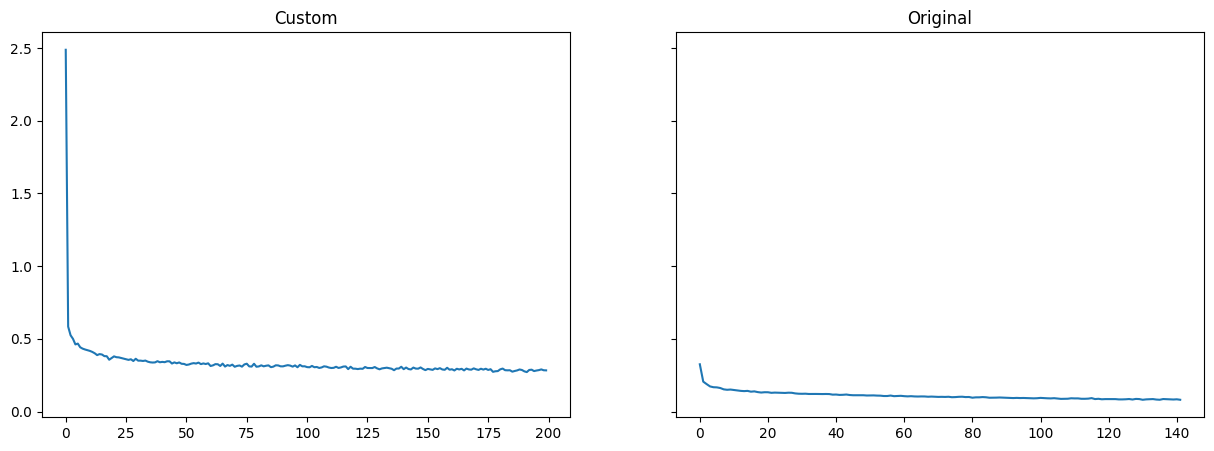

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

reload(perceptron)
from perceptron import MLPRegressor

mlp = MLPRegressor((50, 50, 50), activation='tanh', learning_rate='adaptive', 
                   random_state=42, learning_rate_init=0.01, tol=0.005)
mlp = make_pipeline(StandardScaler(), mlp).fit(X_train, y_train)
y_test_pred = mlp.predict(X_test)
cus_iter = mlp[-1].n_iter_
cus_loss = mlp[-1].loss_
cus_rmse = root_mean_squared_error(y_test, y_test_pred)
ax[0].plot(np.arange(cus_iter), mlp[-1].loss_curve_)
ax[0].set_title('Custom')


from sklearn.neural_network import MLPRegressor
mlp_org = MLPRegressor(hidden_layer_sizes=(50, 50, 50), activation='tanh', 
                       random_state=42, learning_rate='adaptive', learning_rate_init=0.01)
mlp_org = make_pipeline(StandardScaler(), mlp_org).fit(X_train, y_train)
y_test_pred = mlp_org.predict(X_test)
org_rmse = root_mean_squared_error(y_test, y_test_pred)
org_iter = mlp_org[-1].n_iter_
org_loss = mlp_org[-1].loss_
ax[1].plot(np.arange(org_iter), mlp_org[-1].loss_curve_)
ax[1].set_title('Original')


pd.DataFrame([
    [cus_rmse, org_rmse],
    [cus_iter, org_iter],
    [cus_loss, org_loss]
], ['RMSE', 'n Iters', 'Loss'], ['Custom', 'Original'])

In [47]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor
import time

models = [
    make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(30, 30, 30), random_state=42)),
    RandomForestRegressor(random_state=42),
    DecisionTreeRegressor(random_state=42),
    KNeighborsRegressor(),
    make_pipeline(StandardScaler(), SGDRegressor(random_state=42))
]

In [48]:
data = []
pattern = {'Fit Time': None, 'Train RMSE': None, 'Test RMSE': None}

for model in models:
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    current = pattern.copy()
    current['Fit Time'] = end - start
    current['Train RMSE'] = root_mean_squared_error(y_train, model.predict(X_train))
    current['Test RMSE']  = root_mean_squared_error(y_test, model.predict(X_test))
    data.append(current)

In [49]:
from sklearn.pipeline import Pipeline

rows = [m[-1].__class__.__name__ if isinstance(m, Pipeline) else m.__class__.__name__
        for m in models]
pd.DataFrame(data, rows)

,Fit Time,Train RMSE,Test RMSE
MLPRegressor,15.393064,4.746455e-01,0.513919
RandomForestRegressor,20.483784,1.911504e-01,0.504218
DecisionTreeRegressor,0.302826,3.013482e-16,0.726995
KNeighborsRegressor,0.024225,8.596209e-01,1.064059
SGDRegressor,0.045342,7.297371e-01,0.765137
